## Cell 0 — Setup + input check

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

EXP_DIR = Path.cwd()
if str(EXP_DIR) not in sys.path:
    sys.path.insert(0, str(EXP_DIR))
import nli_lib as lib

lib.OUT_DIR.mkdir(exist_ok=True)
lib.TABLES_DIR.mkdir(exist_ok=True)
lib.STATS_DIR.mkdir(exist_ok=True)
lib.FIGURES_DIR.mkdir(exist_ok=True)

REQUIRED = ['pre_fix/pairing_pre_topic_fix.csv', 'pre_fix/adjudicated_v2_prefix.csv',
            'pre_fix/human_review_prefix.csv']
missing = [f for f in REQUIRED if not (lib.DATA_DIR / f).exists()]
if missing:
    raise FileNotFoundError(f'Missing inputs: {missing}')
print('[OK] All required inputs present (pre-fix pilot snapshot)')

[OK] All required inputs present


## Cell 1 — Load pairing + build hybrid GT

In [2]:
pairing_pre = pd.read_csv(lib.PRE_FIX_DIR / "pairing_pre_topic_fix.csv", low_memory=False)
pairing_post = pd.read_csv(lib.DATA_DIR / "pairing.csv", low_memory=False)
human_v1 = pd.read_csv(lib.PRE_FIX_DIR / "human_review_prefix.csv", low_memory=False)
adj_v2 = pd.read_csv(lib.PRE_FIX_DIR / "adjudicated_v2_prefix.csv", low_memory=False)

print(f'pre-fix pairing : {pairing_pre.shape}')
print(f'post-fix pairing: {pairing_post.shape}  (only needed for hybrid GT carrier columns)')
print(f'human_v1: {len(human_v1)}, adj_v2: {len(adj_v2)}')

gt_hybrid = lib.build_hybrid_gt(human_v1, adj_v2, pairing_post=pairing_post)
print(f'\ngt_hybrid: {len(gt_hybrid)} rows  sources={gt_hybrid["gt_source"].value_counts().to_dict()}')

p_hybrid = lib.derive_correct_flags(lib.filter_universe(lib.apply_gt_to_pairing(pairing_pre, gt_hybrid)))
print(f'\nFiltered universe (hybrid GT, pre-fix): n={len(p_hybrid)}')
print(f'(legacy summary_stats_hybrid.json reports n_universe_filtered=8620)')

pre-fix pairing : (8680, 39)
post-fix pairing: (8670, 39)  (only needed for hybrid GT carrier columns)
human_v1: 120, adj_v2: 2550

gt_hybrid: 2550 rows  sources={'arbiter_v2': 2430, 'human': 120}

Filtered universe (hybrid GT, pre-fix): n=8620
(legacy summary_stats_hybrid.json reports n_universe_filtered=8620)


## Cell 2 — T1 Universe + T2 Marginals + T3 Pairwise κ

In [3]:
marginals = lib.per_variant_marginals(p_hybrid)
print('T2 — Variant marginals (universe pre-fix):')
print(marginals.to_string(index=False))
marginals.to_csv(lib.TABLES_DIR / 'T_TN3pre_T2_variant_marginals.csv', index=False)

kappa_pair = lib.pairwise_kappa_variants(p_hybrid)
print('\nT3 — Pairwise Cohen κ on status:')
print(kappa_pair.to_string(index=False))
kappa_pair.to_csv(lib.TABLES_DIR / 'T_TN3pre_T3_pairwise_kappa.csv', index=False)

k_a0_a1 = float(kappa_pair.loc[(kappa_pair['variant_a'] == 'a0') & (kappa_pair['variant_b'] == 'a1'), 'cohen_kappa'].iloc[0])
k_a0_vn = float(kappa_pair.loc[(kappa_pair['variant_a'] == 'a0') & (kappa_pair['variant_b'] == 'v_new'), 'cohen_kappa'].iloc[0])
print(f'\nκ(A0, A1) = {k_a0_a1:.4f}  (thesis: 0.72)')
print(f'κ(A0, V_new) = {k_a0_vn:.4f}  (thesis: 0.56)')

T2 — Variant marginals (universe pre-fix):
variant  n_total  n_pass  n_partial  n_no_evidence  rate_pass  rate_partial  rate_no_evidence
     a0     8620    2285        838           5497     0.2651        0.0972            0.6377
     a1     8620    2342        799           5479     0.2717        0.0927            0.6356
     a2     8620    1803        542           6275     0.2092        0.0629            0.7280
  v_new     8620    1785        584           6251     0.2071        0.0677            0.7252



T3 — Pairwise Cohen κ on status:
variant_a variant_b    n  agreement_rate  cohen_kappa
       a0        a1 8620          0.8561       0.7199
       a0        a2 8620          0.8007       0.5797
       a0     v_new 8620          0.7922       0.5636
       a1        a2 8620          0.7972       0.5728
       a1     v_new 8620          0.7961       0.5720
       a2     v_new 8620          0.8768       0.7098

κ(A0, A1) = 0.7199  (thesis: 0.72)
κ(A0, V_new) = 0.5636  (thesis: 0.56)


## Cell 3 — T4 E1 (V_new vs A0, hybrid GT)

In [4]:
e1_hybrid = lib.e1_metrics(p_hybrid)

t4 = pd.DataFrame([{
    'ground_truth': 'hybrid',
    'n_universe': e1_hybrid['n'],
    'a0_acc': round(e1_hybrid['a0_acc'], 4),
    'v_new_acc': round(e1_hybrid['v_new_acc'], 4),
    'v_new_minus_a0_pp': e1_hybrid['v_new_minus_a0_pp'],
    'mcnemar_p': round(e1_hybrid['mcnemar']['p_value'], 4),
    'boot_ci_lo_pp': round(100 * e1_hybrid['bootstrap_diff_per_report']['ci_95'][0], 2),
    'boot_ci_hi_pp': round(100 * e1_hybrid['bootstrap_diff_per_report']['ci_95'][1], 2),
}])
print('T4 — E1 (V_new − A0) under hybrid GT:')
print(t4.to_string(index=False))
t4.to_csv(lib.TABLES_DIR / 'T_TN3pre_T4_e1.csv', index=False)

print('\nThesis §5.3.1 / Phụ lục D: hybrid GT → E1 = +1.26 pp (V_new > A0)')

T4 — E1 (V_new − A0) under hybrid GT:
ground_truth  n_universe  a0_acc  v_new_acc  v_new_minus_a0_pp  mcnemar_p  boot_ci_lo_pp  boot_ci_hi_pp
      hybrid        8620  0.8646     0.8771               1.25      0.009          -0.81           2.84

Thesis §5.3.1 / Phụ lục D: hybrid GT → E1 = +1.26 pp (V_new > A0)


## Cell 4 — T5 E2b factorial decomposition (hybrid GT, 3 effects)

In [5]:
e2b_hybrid = lib.e2b_factorial(p_hybrid)

t5_rows = []
for eff_label, eff_key in [('REORDER', 'main_effect_reorder'), ('HINT', 'main_effect_hint'), ('INTERACTION', 'interaction_reorder_x_hint')]:
    e = e2b_hybrid[eff_key]
    t5_rows.append({
        'gt': 'hybrid',
        'effect': eff_label,
        'point_pp': e['point_pp'],
        'ci_lo_pp': e['ci_95_pp'][0],
        'ci_hi_pp': e['ci_95_pp'][1],
        'p_value': e['p_value'],
    })
t5 = pd.DataFrame(t5_rows)
print('T5 — E2b factorial (REORDER × HINT) under hybrid GT:')
print(t5.to_string(index=False))
t5.to_csv(lib.TABLES_DIR / 'T_TN3pre_T5_e2b_factorial.csv', index=False)

print('\nThesis §5.3.1 (hybrid GT):')
print('  REORDER main = -0.08 pp')
print('  HINT    main = +1.10 pp')
print('  INTERACTION  = -0.29 pp')

T5 — E2b factorial (REORDER × HINT) under hybrid GT:
    gt      effect  point_pp  ci_lo_pp  ci_hi_pp  p_value
hybrid     REORDER   -0.1420   -0.6565    0.3208    0.616
hybrid        HINT    1.2045   -0.4773    2.8302    0.160
hybrid INTERACTION   -0.3187   -1.1607    0.4301    0.462

Thesis §5.3.1 (hybrid GT):
  REORDER main = -0.08 pp
  HINT    main = +1.10 pp
  INTERACTION  = -0.29 pp


## Cell 5 — T6 Per-phase HINT effect (hybrid GT)

In [6]:
ppb_hybrid = lib.per_phase_breakdown(p_hybrid)
print('T6 — Per-phase variant accuracy (hybrid GT):')
pv = ppb_hybrid.pivot(index='phase', columns='variant', values='rate_correct').reset_index()
print(pv.to_string(index=False))
pv.to_csv(lib.TABLES_DIR / 'T_TN3pre_T6_per_phase.csv', index=False)

phases = sorted(p_hybrid['phase'].unique())
ppb_pivot = pv.set_index('phase')
hint_main_per_phase = {ph: (ppb_pivot.loc[ph, 'a2'] + ppb_pivot.loc[ph, 'v_new'])/2 - (ppb_pivot.loc[ph, 'a0'] + ppb_pivot.loc[ph, 'a1'])/2 for ph in phases}
print('\nHINT main per phase:')
for ph, eff in hint_main_per_phase.items():
    print(f'  {ph}: HINT = {eff*100:+.2f} pp')

T6 — Per-phase variant accuracy (hybrid GT):
 phase     a0     a1     a2  v_new
phase3 0.8516 0.8550 0.8604 0.8638
phase5 0.7995 0.7988 0.8277 0.8205
phase6 0.9138 0.9141 0.9240 0.9207

HINT main per phase:
  phase3: HINT = +0.88 pp
  phase5: HINT = +2.50 pp
  phase6: HINT = +0.84 pp


## Cell 6 — F3/F4 figures

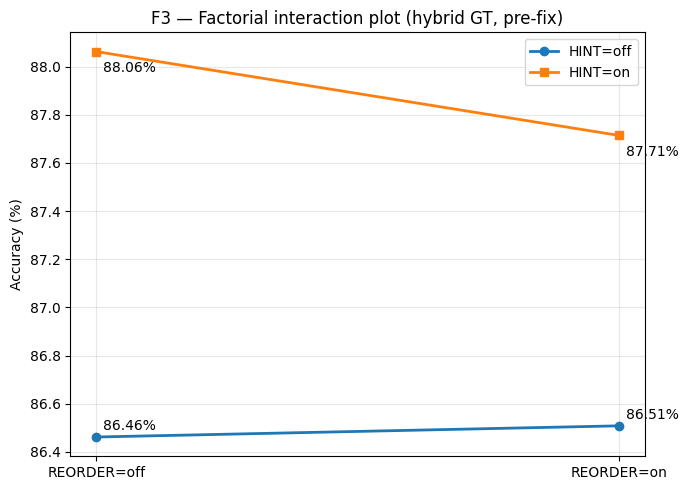

Saved: F3_factorial_interaction.png


In [7]:
acc_hybrid = {v: float(p_hybrid[f'{v}_correct'].astype(float).mean()) for v in lib.VARIANTS}

fig, ax = plt.subplots(figsize=(7, 5))
x_vals = ['REORDER=off', 'REORDER=on']
hint_off = [acc_hybrid['a0'] * 100, acc_hybrid['a1'] * 100]
hint_on  = [acc_hybrid['a2'] * 100, acc_hybrid['v_new'] * 100]
ax.plot(x_vals, hint_off, marker='o', label='HINT=off', linewidth=2)
ax.plot(x_vals, hint_on,  marker='s', label='HINT=on',  linewidth=2)
ax.set_ylabel('Accuracy (%)')
ax.set_title('F3 — Factorial interaction plot (hybrid GT, pre-fix)')
ax.legend()
ax.grid(alpha=0.3)
for xi, (off, on) in enumerate(zip(hint_off, hint_on)):
    ax.annotate(f'{off:.2f}%', (xi, off), textcoords='offset points', xytext=(5, 5))
    ax.annotate(f'{on:.2f}%', (xi, on),  textcoords='offset points', xytext=(5, -15))
plt.tight_layout()
plt.savefig(lib.FIGURES_DIR / 'F3_factorial_interaction.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: F3_factorial_interaction.png')

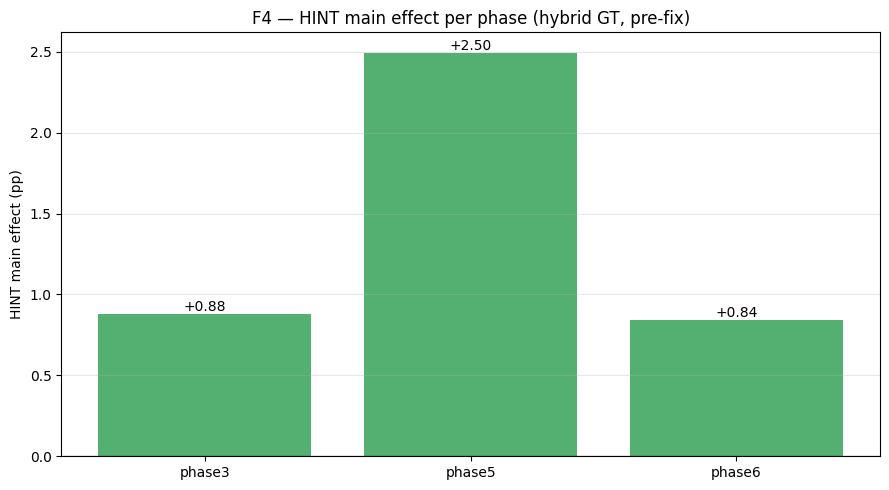

Saved: F4_hint_per_phase.png


In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
phases_l = [p for p in phases if p in ppb_pivot.index]
hint_eff_pct = [hint_main_per_phase[ph] * 100 for ph in phases_l]
colors = ['#d7191c' if v < 0 else '#1a9641' for v in hint_eff_pct]
bars = ax.bar(phases_l, hint_eff_pct, color=colors, alpha=0.75)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('HINT main effect (pp)')
ax.set_title('F4 — HINT main effect per phase (hybrid GT, pre-fix)')
for bar, val in zip(bars, hint_eff_pct):
    ax.annotate(f'{val:+.2f}', xy=(bar.get_x() + bar.get_width() / 2, val), ha='center', va='bottom' if val > 0 else 'top')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(lib.FIGURES_DIR / 'F4_hint_per_phase.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: F4_hint_per_phase.png')

## Cell 7 — Verification summary `[PASS/FAIL]`

In [9]:
checks = []

r_pp = e2b_hybrid['main_effect_reorder']['point_pp']
h_pp = e2b_hybrid['main_effect_hint']['point_pp']
i_pp = e2b_hybrid['interaction_reorder_x_hint']['point_pp']
checks.append(('REORDER main ~ -0.08 pp (thesis)', abs(r_pp - (-0.08)) < 0.5, f'r={r_pp:+.2f}pp'))
checks.append(('HINT main ~ +1.10 pp (thesis)', abs(h_pp - 1.10) < 0.5, f'h={h_pp:+.2f}pp'))
checks.append(('Interaction ~ -0.29 pp (thesis)', abs(i_pp - (-0.29)) < 0.5, f'i={i_pp:+.2f}pp'))

e1_h_pp = e1_hybrid['v_new_minus_a0_pp']
checks.append(('E1 hybrid GT > 0', e1_h_pp > 0, f'{e1_h_pp:+.2f}pp'))
checks.append(('E1 hybrid ~ +1.26 pp (thesis)', abs(e1_h_pp - 1.26) < 0.5, f'{e1_h_pp:+.2f}pp'))

checks.append(('κ(A0, A1) ~ 0.72', abs(k_a0_a1 - 0.72) < 0.02, f'{k_a0_a1:.4f}'))
checks.append(('κ(A0, V_new) ~ 0.56', abs(k_a0_vn - 0.56) < 0.02, f'{k_a0_vn:.4f}'))

print('=' * 75)
print('TN3 Pre-fix Verification Summary')
print('=' * 75)
all_pass = True
for name, ok, info in checks:
    tag = '[PASS]' if ok else '[FAIL]'
    print(f'  {tag} {name:48s}  {info}')
    if not ok:
        all_pass = False
print('=' * 75)
print(f'[{"ALL PASS" if all_pass else "FAIL"}]')
print('=' * 75)

TN3 Pre-fix Verification Summary
  [PASS] REORDER main ~ -0.08 pp (thesis)                  r=-0.14pp
  [PASS] HINT main ~ +1.10 pp (thesis)                     h=+1.20pp
  [PASS] Interaction ~ -0.29 pp (thesis)                   i=-0.32pp
  [PASS] E1 hybrid GT > 0                                  +1.25pp
  [PASS] E1 hybrid ~ +1.26 pp (thesis)                     +1.25pp
  [PASS] κ(A0, A1) ~ 0.72                                  0.7199
  [PASS] κ(A0, V_new) ~ 0.56                               0.5636
[ALL PASS]
